# 定理27　無明起行定理 — 「川の流れ」と「自分で漕いだ分」を分ける数値例

> **この notebook の位置づけ。** 数値シミュレーション（説明用のトイ例）で、証明ではありません。
> Lean で確かめた範囲は最後の「Lean との対応」に書きます。原文の主張・この例が見せること・仏教的な読み（解釈）は別の見出しに分けます。
> **原文は「無明」「行」を、定理26の数理体系の内部で定義された“モデル相対的・操作的な概念”と断っています。** パーリ語原典（SN 12.2 の三種の行など）の全体を一本の式に還元するものではありません。

## 1. 定理27は何を言っているのか

十二縁起の最初の一本の矢印 **「無明に縁りて行が起こる」（avijjāpaccayā saṅkhārā）** だけを数学にしたものです（他の11本は何も主張しません）。結論は2段階です。

* **① 無明 $\Rightarrow$ メーターが下がる（定理26だけで言える）。** 無明 $=$「苦ゼロの部屋 $\mathcal N_\top$ の外にいる」（位置の事実）。高さメーター（Lyapunov 関数）$W_\top$ は止まらずに下がります。

$$
\mathrm{Avijj\bar a}_{27}\ \Longrightarrow\ \mathrm{Des}_{27}(t)\ \ge\ \lambda\,W_\top\ \ge\ \lambda c_1\operatorname{dist}(x,\mathcal N_\top)^2>0\qquad(27.6)
$$

* **② 「それは本人の行だ」と言うには、条件27-A が追加で要る。** メーターが下がっているだけでは、川の流れに乗っているだけかもしれません。

### 条件27-A：流れの分を引き算する

状態は $\dot x=f_0(x,t)+G(x,t)\,u$（**制御アフィン系**）に従うとします。$f_0$ は **自然ドリフト**（誰も何もしなくても動く分＝川の流れ）、$G$ は **実アクチュエータ**（入力が実際に状態へ効く経路＝オールと水の関係）。
独立に固定した **基準入力** $u_{\mathrm{tr}}$（生命維持などの素の営み）を置き、**志向信号**

$$
\eta_{27}=u_0-u_{\mathrm{tr}},\qquad F_{\mathrm{tr}}=f_0+G\,u_{\mathrm{tr}}
$$

を作ります。**条件27-A2**：**基準閉ループだけではメーターの高さは変わらない**：

$$
\frac{\partial W_\top}{\partial t}+\nabla W_\top^{T}\,F_{\mathrm{tr}}=0\qquad(27.A2)
$$

このとき

$$
\mathrm{Des}_{27}=-\nabla W_\top^{T}G\,\eta_{27}\qquad(27.7)
$$

（下降の理由が、ちょうど「余分に漕いだ分」に一致する）。**行** は $\mathrm{Saṅkhārā}_{27}:\Leftrightarrow-\nabla W_\top^{T}G\eta_{27}>0$（27.5）。無明なら行が成立し、$\eta_{27}\ne0$。

$$
\|\eta_{27}\|\ \ge\ \frac{\lambda W_\top}{L_{27}}\quad(\|G^T\nabla W_\top\|\le L_{27})\qquad(27.8)
$$

そして部屋に入れば行の寄与は $0$（27.9）。**ただし零になるのは「無明条件付きの正のアクチュエータ寄与」だけで、$\eta_{27}$ 自体、生命活動、接線運動が止まるわけではありません。**

### 但し書き（原文）

* **27-A2 が欠けると、帰属がずれます**：自然ドリフトによる下降まで「行」と数える／あるいは数え損なう、という問題が出ます。**基準入力を先に独立に固定** しておくのは、あとから都合よく切り直して「これが行だ」と呼び替えられないようにするためです。

### 記号とコード変数の対応

| 原文の記号 | 意味 | このコードでは |
| --- | --- | --- |
| 状態 $x=(r,\varphi)$ | $r$：輪 $\mathcal N=\{r=0\}$ からのずれ、$\varphi$：輪の上の位相 | `r`, `phi` |
| 高さメーター $W=\tfrac12r^2$ | 無明残差。$\nabla W=(r,0)$ | `gradW` |
| 自然ドリフト $f_0=(-\mu r,0)$ | 川の流れ（$\mu=0.5$） | `f0` |
| アクチュエータ $G=I$ | 入力がそのまま効く | （単位行列） |
| 指定入力 $u_0=(-\kappa r,\omega)$ | $\kappa=1,\ \omega=1.5$ | `u0` |
| 基準入力 A $u_{\mathrm{tr}}=(\mu r,\omega)$ | 流れを打ち消す基準。**27-A2 成立** | `utr` の `"A"` |
| 基準入力 B $u_{\mathrm{tr}}=(0,\omega)$ | 流れを無視した基準。**27-A2 破れ** | `utr` の `"B"` |
| 下降率 $\mathrm{Des}_{27}=-\nabla W^T(f_0+u_0)$ | $-\dot W$ | `Des` |
| 帰属 $-\nabla W^TG\eta_{27}$ | 余分な漕ぎの効果 | `attrib` |
| 減衰率 $\lambda=2(\mu+\kappa)=3$ | $W=\tfrac12r^2$ の減衰率 | `lam_W` |

## 2. なぜこれが「定理27の例」と言えるのか

* **自然ドリフトと漕ぎの両方がある。** 状態の動きは $\dot r=-\mu r-\kappa r=-(\mu+\kappa)r$：川の流れ $-\mu r$（勝手に輪へ戻る分）と、指定入力 $-\kappa r$（漕いで戻る分）の和です。下降率は $\mathrm{Des}_{27}=(\mu+\kappa)r^2$。
* **基準入力を2通り置く。**
  * **A：$u_{\mathrm{tr}}=(\mu r,\omega)$（流れを打ち消す基準）。** $F_{\mathrm{tr}}=f_0+u_{\mathrm{tr}}=(0,\omega)$、$\nabla W\cdot F_{\mathrm{tr}}=0$ なので **27-A2 成立**。志向信号 $\eta_{27}=(-(\mu+\kappa)r,\ 0)$、帰属 $=(\mu+\kappa)r^2=\mathrm{Des}_{27}$。**帰属が完全。**
  * **B：$u_{\mathrm{tr}}=(0,\omega)$（流れを無視した基準）。** $F_{\mathrm{tr}}=(-\mu r,\omega)$、$\nabla W\cdot F_{\mathrm{tr}}=-\mu r^2\ne0$ で **27-A2 破れ**（基準だけで $W$ が下がってしまう）。帰属は $\kappa r^2$ で、$\mathrm{Des}_{27}$ と **$\mu r^2$ だけずれる**。
* **輪の中（$r=0$）。** $\nabla W=0$ なので行の寄与は $0$。ただし位相 $\varphi'=\omega$ は残る（動的寂静）。

## 3. 各 $r$ での恒等式の確認

In [1]:
# %% 準備
import numpy as np
import matplotlib.pyplot as plt
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # フォント警告を抑制
try:
    import japanize_matplotlib  # Colab: !pip -q install japanize-matplotlib
except Exception:
    plt.rcParams["font.family"] = ["Noto Sans CJK JP", "IPAexGothic", "sans-serif"]

mu, kappa, omega, lam_W = 0.5, 1.0, 1.5, 2 * (0.5 + 1.0)   # W=½r² の減衰率 λ=2(μ+κ)
def report(r):
    gradW = np.array([r, 0.0])                              # ∇W=(r,0)
    f0 = np.array([-mu * r, 0.0]); u0 = np.array([-kappa * r, omega])
    Des = -(gradW @ (f0 + u0))                              # −Ẇ (軌道微分)
    out = {}
    for name, utr in {"A": np.array([mu * r, omega]), "B": np.array([0.0, omega])}.items():
        A2_residual = gradW @ (f0 + utr)                    # (27.A2) の左辺(=0 が条件)
        attrib = -(gradW @ (u0 - utr))                      # −∇Wᵀ G η27
        out[name] = dict(A2=A2_residual, attrib=attrib, gap=Des - attrib, eta=np.linalg.norm(u0 - utr))
    return Des, out

rs = np.array([2.0, 1.0, 0.1, 0.0])
rows = [report(r) for r in rs]

`report(r)` は、各 $r$ で、下降率 `Des`、27-A2 の左辺（`A2`）、帰属（`attrib`）、取りこぼし（`gap = Des - attrib`）を A・B それぞれで計算します。

## 4. 軌道：無明の間だけ行が働く

In [2]:
# %% 軌道 (A のとき: 無明の間だけ行が働き、φ は回り続ける)
dt, r, phi = 0.01, 2.0, 0.0; R, Att, PH = [], [], []
for _ in range(1000):
    Des, o = report(r); R.append(r); Att.append(o["A"]["attrib"]); PH.append(phi)
    r += dt * (-(mu + kappa) * r); phi += dt * omega
R, Att, PH = map(np.array, (R, Att, PH))

基準 A のもとで、$r_0=2$ から $\dot r=-(\mu+\kappa)r$、$\dot\varphi=\omega$ を $dt=0.01$、1000 ステップ（時間 10）進め、各ステップの行の寄与を記録します。

## 5. 図を読む

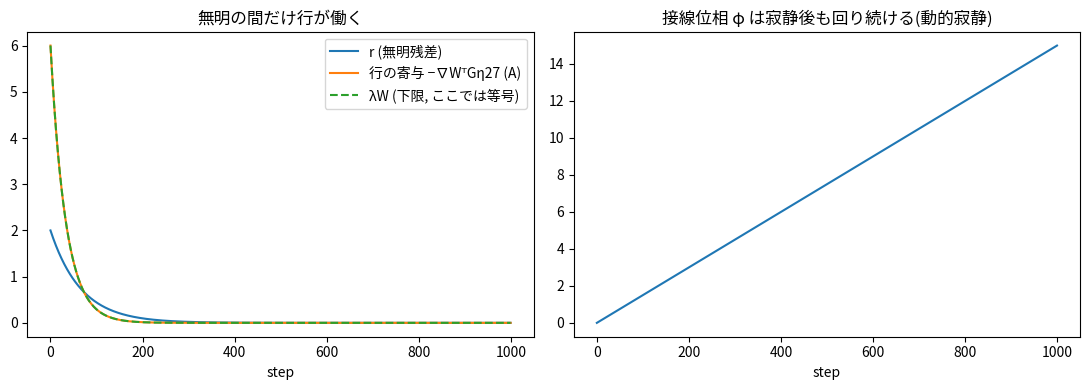

In [3]:
# %% 可視化
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(R, label="r (無明残差)"); ax[0].plot(Att, label="行の寄与 −∇WᵀGη27 (A)"); ax[0].plot(lam_W * 0.5 * R**2, "--", label="λW (下限, ここでは等号)")
ax[0].legend(); ax[0].set_xlabel("step"); ax[0].set_title("無明の間だけ行が働く")
ax[1].plot(PH); ax[1].set_xlabel("step"); ax[1].set_title("接線位相 φ は寂静後も回り続ける(動的寂静)")
plt.tight_layout(); plt.show()

### 左：無明の間だけ行が働く

* **青（$r$、無明残差）：** $2$ から指数的に $0$ へ。
* **橙（行の寄与 $-\nabla W^TG\eta_{27}$、基準 A）と緑の破線（$\lambda W$）：** **完全に重なって**、$r=2$ のとき $6$ から出発し、青より速く $0$ へ落ちます。橙は $(\mu+\kappa)r^2=1.5\,r^2$、緑は $\lambda W=3\cdot\tfrac12r^2=1.5\,r^2$ で **等号** です。(27.7) の $\mathrm{Des}_{27}\ge\lambda W_\top$ が、この例では等号で成り立っています。
* 約 300 ステップ（3 秒）以降は、すべて見分けがつかないほど小さくなります。**無明が消えれば行も消えます**（輪に着けば寄与は $0$）。

### 右：位相 $\varphi$

**一直線に増え続けます**（1000 ステップで約 $15=\omega\times10$）。左の行の寄与がほぼ $0$ になった後も、**位相は同じ速さで回り続けています**。これが「寂静は静止ではない（動的寂静）」＝(27.9) の「零になるのは無明条件付きの正のアクチュエータ寄与だけで、接線運動は止まらない」の絵です。

## 6. 数値確認

In [4]:
# %% 数値確認
for r, (Des, o) in zip(rs, rows):
    Des = abs(Des) if abs(Des) < 1e-15 else Des
    print(f"r={r}: Des27={Des:.4f} | A: 帰属={o['A']['attrib']:.4f}, A2残差={o['A']['A2']:.4f} | "
          f"B: 帰属={o['B']['attrib']:.4f}, A2残差={o['B']['A2']:.4f}, 取りこぼし={o['B']['gap']:.4f}")
    if r > 0:
        assert Des >= lam_W * 0.5 * r**2 - 1e-12                     # (27.6) Des ≥ λW
        assert abs(o["A"]["gap"]) < 1e-12 and abs(o["A"]["A2"]) < 1e-12   # (27.7)
        assert abs(o["B"]["gap"] - mu * r**2) < 1e-12                # 27-A2 破れ → 自然ドリフト分だけずれる
    else:
        assert abs(Des) < 1e-12 and abs(o["A"]["attrib"]) < 1e-12          # 寂静内: 無明条件付き寄与は 0 (27.9)
assert abs(PH[-1] - PH[0]) > 10                                      # φ は動き続ける

r=2.0: Des27=6.0000 | A: 帰属=6.0000, A2残差=0.0000 | B: 帰属=4.0000, A2残差=-2.0000, 取りこぼし=2.0000
r=1.0: Des27=1.5000 | A: 帰属=1.5000, A2残差=0.0000 | B: 帰属=1.0000, A2残差=-0.5000, 取りこぼし=0.5000
r=0.1: Des27=0.0150 | A: 帰属=0.0150, A2残差=0.0000 | B: 帰属=0.0100, A2残差=-0.0050, 取りこぼし=0.0050
r=0.0: Des27=0.0000 | A: 帰属=-0.0000, A2残差=0.0000 | B: 帰属=-0.0000, A2残差=0.0000, 取りこぼし=0.0000


出力の表（$\mu=0.5,\ \kappa=1$）：

| $r$ | $\mathrm{Des}_{27}$ | A：帰属 | A：27-A2 残差 | B：帰属 | B：27-A2 残差 | B：取りこぼし |
| --- | --- | --- | --- | --- | --- | --- |
| 2.0 | 6.0 | 6.0 | 0 | 4.0 | $-2.0$ | 2.0 |
| 1.0 | 1.5 | 1.5 | 0 | 1.0 | $-0.5$ | 0.5 |
| 0.1 | 0.015 | 0.015 | 0 | 0.01 | $-0.005$ | 0.005 |
| 0.0 | 0 | 0 | 0 | 0 | 0 | 0 |

* **A：** 27-A2 残差は常に $0$、帰属 $=\mathrm{Des}_{27}$（(27.7) が成立）。
* **B：** 27-A2 残差は $-\mu r^2$（$r=2$ で $-2$）。帰属は $\kappa r^2$（$r=2$ で $4$）で、**取りこぼしは $\mu r^2$**（$r=2$ で $2$）。**27-A2 が破れると (27.7) の等式が崩れる**、という但し書きの数値例です。基準 B の「流れを無視した基準」自身が $W$ を $\mu r^2$ だけ下げてしまうので、「基準だけでは高さが変わらない」という前提が成り立たなくなります。
* **$r=0$：** どちらでも $\mathrm{Des}=0$、行の寄与 $=0$。

`assert` は、(27.6)（$\mathrm{Des}\ge\lambda W$）、A の (27.7)（取りこぼし $0$）、B の取りこぼし $=\mu r^2$、寂静内の寄与 $0$（(27.9)）、位相が動き続ける、を確認しています。

## 7. 仏教的な意義（解釈）

> 原文の説明にそった **思想的な読み** で、Lean で形式化された数理結論そのものではありません。

* **「無明に縁りて行が起こる」＝まだ寂静に達していないなら、必ず何かを漕いでいる。** 左の図：輪の外（無明）にいる間は、行の寄与が正で、輪に着けば $0$。原文は「寂静に達していないなら、必ず何かを漕いでいる。逆に、部屋の中に入ってしまえば、その漕ぎはゼロになる」と要約します。
* **「川の流れ」と「自分で漕いだ分」を分ける。** 条件27-A は、「ロープウェイのおかげで標高計が減っている」場合を、本人の歩みから差し引く仕掛けです。基準 B はそれを怠った場合で、ずれが出ることを数値で見せています。
* **ゼロになるのは「外へ出ようとする向きの成分」だけ。** 原文は「生きること・考えること・他者に応えることが止まるわけではない」と述べます。右の図の位相の直線がそれです。
* **無明は気分でも頭の悪さでもない。** 原文：「いま自分がいる場所が、苦がゼロになる集合の外側だという、位置についての事実」。ここでは $r\neq0$ にあたります。「心理量ではなく、部屋からどれだけ離れているかという位置の量」です。
* **限界の明記（原文）。** この「行」は、無明残差の減少へ正に寄与する実アクチュエータ成分が存在する、という限定された事態です。身体的・言語的・心的な三種すべての行を、この一本の内積に還元するものではありません。十二縁起の残り11本の矢印についても何も主張しません。

## 8. Lean との対応

対応ファイル：`Tomabechi/Examples/Theorem27_AvijjaSankhara.lean`。一般定理の輪モデルへの適用は `Theorem27_Operational.lean`、線形ゲイン族への拡張は `Theorem26_27_ControlClasses.lean`（別の notebook `theorem26_27_dynamic_quiescence` で扱いました）。

| | 内容 | 状態 |
| --- | --- | --- |
| (27.7)(27.8) の **代数核** | 任意の $\mu,\kappa,\omega,r$ で、A：帰属が完全（$\mathrm{Des}=(\mu+\kappa)r^2=-\langle\nabla W,G\eta_{27}\rangle$、27-A2 の左辺 $=0$）、B：27-A2 の左辺 $=-\mu r^2$、帰属 $=\kappa r^2$ で $\mu r^2$ だけずれる | 証明済 |
| 寂静内（$r=0$） | $\nabla W=0$ なので行の寄与 $0$、位相 $\varphi'=\omega$ は残る | 証明済 |
| **任意パラメータ**（$\mu\ge0,\ \kappa>0,\ \omega$）の解析核 | 厳密な指数軌道（半径 $r_0e^{-(\mu+\kappa)(s-T)}$、位相は等速）の ODE・Dini 微分・再始動。最適値 $=$ Lyapunov 関数 $V=\dfrac{3r^2}{1+2(\mu+\kappa)}$（割引費用の厳密値）、基準入力の相殺、行の帰属、零集合 $=$ 輪、$W=\frac{3}{1+2\lambda}\mathrm{dist}^2$。これらを定理27の一般軌道カーネルへ渡して、無明 $\Leftrightarrow$ 下降＋作動量 a.e. 正を得る。有界可測ゲイン族 $0\le k\le\kappa$ の中で最大ゲインが費用最小 | 証明済 |
| **2 次元ベクトル入力での接続**（$\mu=\kappa=\tfrac12,\ \omega=\tfrac32$） | 最大ゲインの入力・基準入力・自然ドリフト・軌道が、運用モデルのものと**ベクトルとして一致**。2 次元の 24・26 のデータから 24→26→27 の一般カーネルを適用して定理27の結論を得る | 証明済 |
| 27-A2 を破る B 側 | 代数的な確認（上の「代数核」）まで。一般定理27の適用対象外 | 部分 |
| 図の軌道（Euler 法） | 数値のみ | 未証明 |

* 任意パラメータでの 2 次元ベクトル入力側の接続は、固定値 $\mu=\kappa=\tfrac12,\ \omega=\tfrac32$ に限ります。
* 任意の Borel フィードバックへの拡張はしていません（線形ゲイン族に限ります）。